In [1]:
import pandas as pd
from sklearn.metrics import confusion_matrix, accuracy_score
from sklearn.metrics import classification_report
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize

In [2]:
#Se definen las rutas de los datos
ruta=''


In [15]:
resultado = pd.read_csv(ruta+'resultado_ensamble.csv', sep=';',low_memory=False)

### Ensamble de modelos multitarget

In [16]:
resultado_multitarget = resultado[['target','xgb_pred_class','xgb_prob_class_M1_0','xgb_prob_class_M1_1','xgb_prob_class_M1_2','LGBM_M_pred_class','LGBM_M_prob_class_0','LGBM_M_prob_class_1','LGBM_M_prob_class_2','catM_pred_class','catM_prob_class_0','catM_prob_class_1','catM_prob_class_2']]

In [22]:
resultado_multitarget = resultado_multitarget.copy()

In [152]:
resultado_multitarget

,target,xgb_pred_class,xgb_prob_class_M1_0,xgb_prob_class_M1_1,xgb_prob_class_M1_2,LGBM_M_pred_class,LGBM_M_prob_class_0,LGBM_M_prob_class_1,LGBM_M_prob_class_2,catM_pred_class,catM_prob_class_0,catM_prob_class_1,catM_prob_class_2
0,0,0,0.721647,0.003294,0.275058,0,0.543100,0.007794,0.449106,0,0.498254,0.098193,0.403553
1,0,0,0.753516,0.002544,0.243940,0,0.570659,0.006030,0.423311,0,0.537650,0.070808,0.391542
2,0,0,0.809063,0.000722,0.190215,0,0.680698,0.002692,0.316610,0,0.616584,0.066081,0.317335
3,0,0,0.587880,0.007950,0.404170,2,0.377438,0.015553,0.607010,2,0.338180,0.254758,0.407062
4,0,0,0.777471,0.010338,0.212191,0,0.744793,0.018362,0.236845,0,0.488870,0.303400,0.207730
...,...,...,...,...,...,...,...,...,...,...,...,...,...
14205,1,1,0.234091,0.649601,0.116308,1,0.155796,0.775939,0.068266,1,0.220694,0.707353,0.071953
14206,1,0,0.703431,0.064074,0.232495,0,0.605601,0.111636,0.282763,0,0.492776,0.137297,0.369927
14207,1,0,0.453863,0.287520,0.258617,0,0.369013,0.285628,0.345359,2,0.311300,0.318802,0.369897
14208,1,0,0.478834,0.386554,0.134613,1,0.391879,0.479305,0.128816,1,0.212031,0.628849,0.159120


In [ ]:
#votación multitarget
resultado_multitarget['votacion'] = resultado_multitarget[['xgb_pred_class','LGBM_M_pred_class','catM_pred_class']].mode(axis=1)[0]

In [ ]:
#Ensamble de modelos mediante suma de probabilidades

# Para cada clase se suman las probabilidades predichas por los distintos modelos (XGBoost, LightGBM y CatBoost)

resultado_multitarget["votacion_sum0"] = resultado_multitarget[["xgb_prob_class_M1_0", "LGBM_M_prob_class_0", "catM_prob_class_0"]].sum(axis=1)
resultado_multitarget["votacion_sum1"] = resultado_multitarget[["xgb_prob_class_M1_1", "LGBM_M_prob_class_1", "catM_prob_class_1"]].sum(axis=1)
resultado_multitarget["votacion_sum2"] = resultado_multitarget[["xgb_prob_class_M1_2", "LGBM_M_prob_class_2", "catM_prob_class_2"]].sum(axis=1)
# Se selecciona la clase cuya suma de probabilidades sea mayor
cols = ["votacion_sum0", "votacion_sum1", "votacion_sum2"]
resultado_multitarget["votacion"] = (
    resultado_multitarget[cols]
    .idxmax(axis=1)      # obtiene la columna con el valor máximo
    .str[-1]             # extrae el número de clase del nombre de la columna
    .astype(int)         # convierte a entero
)


In [155]:
resultado_multitarget

,target,xgb_pred_class,xgb_prob_class_M1_0,xgb_prob_class_M1_1,xgb_prob_class_M1_2,LGBM_M_pred_class,LGBM_M_prob_class_0,LGBM_M_prob_class_1,LGBM_M_prob_class_2,catM_pred_class,catM_prob_class_0,catM_prob_class_1,catM_prob_class_2,votacion,votacion_sum0,votacion_sum1,votacion_sum2
0,0,0,0.721647,0.003294,0.275058,0,0.543100,0.007794,0.449106,0,0.498254,0.098193,0.403553,0,1.763001,0.109282,1.127717
1,0,0,0.753516,0.002544,0.243940,0,0.570659,0.006030,0.423311,0,0.537650,0.070808,0.391542,0,1.861825,0.079382,1.058793
2,0,0,0.809063,0.000722,0.190215,0,0.680698,0.002692,0.316610,0,0.616584,0.066081,0.317335,0,2.106345,0.069495,0.824160
3,0,0,0.587880,0.007950,0.404170,2,0.377438,0.015553,0.607010,2,0.338180,0.254758,0.407062,2,1.303497,0.278261,1.418242
4,0,0,0.777471,0.010338,0.212191,0,0.744793,0.018362,0.236845,0,0.488870,0.303400,0.207730,0,2.011134,0.332100,0.656766
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14205,1,1,0.234091,0.649601,0.116308,1,0.155796,0.775939,0.068266,1,0.220694,0.707353,0.071953,1,0.610581,2.132892,0.256527
14206,1,0,0.703431,0.064074,0.232495,0,0.605601,0.111636,0.282763,0,0.492776,0.137297,0.369927,0,1.801808,0.313007,0.885186
14207,1,0,0.453863,0.287520,0.258617,0,0.369013,0.285628,0.345359,2,0.311300,0.318802,0.369897,0,1.134176,0.891950,0.973874
14208,1,0,0.478834,0.386554,0.134613,1,0.391879,0.479305,0.128816,1,0.212031,0.628849,0.159120,1,1.082744,1.494708,0.422548


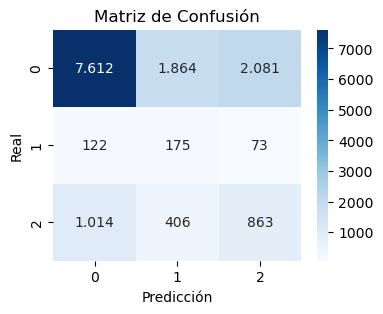

In [159]:
cm = confusion_matrix(resultado_multitarget['target'], resultado_multitarget['votacion'])
# Formatear números con separador de miles "."
cm_fmt = [[f"{int(x):,}".replace(",", ".") for x in row] for row in cm]

plt.figure(figsize=(4, 3))
sns.heatmap(
    cm,
    annot=cm_fmt,
    fmt="",
    cmap="Blues"
)
#sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Matriz de Confusión")
plt.ylabel("Real")
plt.xlabel("Predicción")
plt.show()

In [106]:
# se calcula accuracy del modelo 
accuracy = accuracy_score(
    resultado_multitarget['target'],
    resultado_multitarget['votacion']
)

print(f'Accuracy: {accuracy:.4f}')

Accuracy: 0.6087


In [107]:
#se calcula la matriz de confusión
print(classification_report(
    resultado_multitarget['target'],
    resultado_multitarget['votacion']
))

              precision    recall  f1-score   support

           0       0.87      0.66      0.75     11557
           1       0.07      0.47      0.12       370
           2       0.29      0.38      0.33      2283

    accuracy                           0.61     14210
   macro avg       0.41      0.50      0.40     14210
weighted avg       0.76      0.61      0.67     14210



In [ ]:
#Se promedian las probabilidades por clase

resultado_multitarget['proba_M_0'] = resultado_multitarget[['xgb_prob_class_M1_0','LGBM_M_prob_class_0','catM_prob_class_0']].mean(axis=1)
resultado_multitarget['proba_M_1'] = resultado_multitarget[['xgb_prob_class_M1_1','LGBM_M_prob_class_1','catM_prob_class_1']].mean(axis=1)
resultado_multitarget['proba_M_2'] = resultado_multitarget[['xgb_prob_class_M1_2','LGBM_M_prob_class_2','catM_prob_class_2']].mean(axis=1)

In [15]:
resultado_multitarget

,target,xgb_pred_class,xgb_prob_class_M1_0,xgb_prob_class_M1_1,xgb_prob_class_M1_2,LGBM_M_pred_class,LGBM_M_prob_class_0,LGBM_M_prob_class_1,LGBM_M_prob_class_2,catM_pred_class,catM_prob_class_0,catM_prob_class_1,catM_prob_class_2,votacion,votacion_sum0,votacion_sum1,votacion_sum2,proba_M_0,proba_M_1,proba_M_2
0,0,0,0.721647,0.003294,0.275058,0,0.543100,0.007794,0.449106,0,0.498254,0.098193,0.403553,0.0,1.763001,0.109282,1.127717,0.587667,0.036427,0.375906
1,0,0,0.753516,0.002544,0.243940,0,0.570659,0.006030,0.423311,0,0.537650,0.070808,0.391542,0.0,1.861825,0.079382,1.058793,0.620608,0.026461,0.352931
2,0,0,0.809063,0.000722,0.190215,0,0.680698,0.002692,0.316610,0,0.616584,0.066081,0.317335,0.0,2.106345,0.069495,0.824160,0.702115,0.023165,0.274720
3,0,0,0.587880,0.007950,0.404170,2,0.377438,0.015553,0.607010,2,0.338180,0.254758,0.407062,2.0,1.303497,0.278261,1.418242,0.434499,0.092754,0.472747
4,0,0,0.777471,0.010338,0.212191,0,0.744793,0.018362,0.236845,0,0.488870,0.303400,0.207730,0.0,2.011134,0.332100,0.656766,0.670378,0.110700,0.218922
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14205,1,1,0.234091,0.649601,0.116308,1,0.155796,0.775939,0.068266,1,0.220694,0.707353,0.071953,1.0,0.610581,2.132892,0.256527,0.203527,0.710964,0.085509
14206,1,0,0.703431,0.064074,0.232495,0,0.605601,0.111636,0.282763,0,0.492776,0.137297,0.369927,0.0,1.801808,0.313007,0.885186,0.600603,0.104336,0.295062
14207,1,0,0.453863,0.287520,0.258617,0,0.369013,0.285628,0.345359,2,0.311300,0.318802,0.369897,0.0,1.134176,0.891950,0.973874,0.378059,0.297317,0.324625
14208,1,0,0.478834,0.386554,0.134613,1,0.391879,0.479305,0.128816,1,0.212031,0.628849,0.159120,1.0,1.082744,1.494708,0.422548,0.360915,0.498236,0.140849


#### Se evalua el desempeño del modelo mediante curvas ROC multiclase bajo un esquema one-vs-rest, reportando AUC por clase, y métricas globales micro-average y macro-average.

In [16]:
# Variables reales (target) y probabilidades predichas por el modelo ensamble
y_true = resultado_multitarget['target'].values
y_score = resultado_multitarget[['proba_M_0', 'proba_M_1', 'proba_M_2']].values

# Binarización del target para evaluación multiclase (one-vs-rest)
y_true_bin = label_binarize(y_true, classes=[0, 1, 2])
n_classes = y_true_bin.shape[1]

In [17]:
# Curva ROC individual por clase (enfoque one-vs-rest) 
fpr = {}
tpr = {}
roc_auc = {}

for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_true_bin[:, i], y_score[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

In [18]:
# Micro-average
# Calcula la ROC considerando todas las predicciones conjuntamente
fpr["micro"], tpr["micro"], _ = roc_curve(
    y_true_bin.ravel(), y_score.ravel()
)
roc_auc["micro"] = auc(fpr["micro"], tpr["micro"])

# Macro-average
# Promedia las curvas ROC de todas las clases
all_fpr = np.unique(np.concatenate([fpr[i] for i in range(n_classes)]))
mean_tpr = np.zeros_like(all_fpr)
# Curva ROC para cada clase
for i in range(n_classes):
    mean_tpr += np.interp(all_fpr, fpr[i], tpr[i])

# Promedio de las curvas
mean_tpr /= n_classes

fpr["macro"] = all_fpr
tpr["macro"] = mean_tpr
roc_auc["macro"] = auc(fpr["macro"], tpr["macro"])

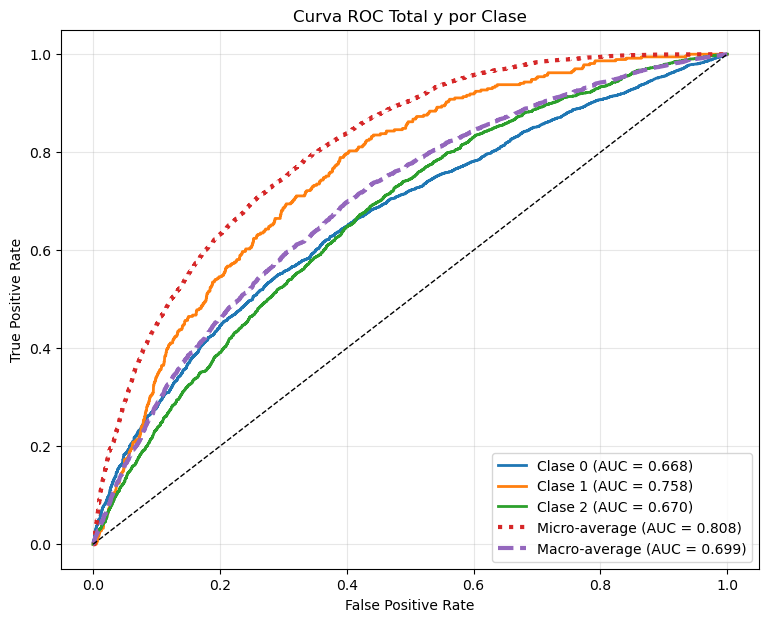

In [19]:
# Visualización de las curvas ROC 

plt.figure(figsize=(9, 7))

# ROC por clase
for i in range(n_classes):
    plt.plot(
        fpr[i], tpr[i],
        lw=2,
        label=f'Clase {i} (AUC = {roc_auc[i]:.3f})'
    )

# ROC micro
plt.plot(
    fpr["micro"], tpr["micro"],
    linestyle=':',
    linewidth=3,
    label=f'Micro-average (AUC = {roc_auc["micro"]:.3f})'
)

# ROC macro
plt.plot(
    fpr["macro"], tpr["macro"],
    linestyle='--',
    linewidth=3,
    label=f'Macro-average (AUC = {roc_auc["macro"]:.3f})'
)

# Azar
plt.plot([0, 1], [0, 1], 'k--', lw=1)

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Curva ROC Total y por Clase')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.show()


#### Se calcularon curvas ROC por clase utilizando un esquema one-vs-rest, junto con una curva ROC global (micro-average) basada en las probabilidades generadas por el ensamble de modelos.

In [75]:
# Target real
y_true = resultado_multitarget['target'].values

# Probabilidades promedio
y_proba = resultado_multitarget[['proba_M_0', 'proba_M_1', 'proba_M_2']].values

# Clases
classes = [0, 1, 2]

# Binarizar target
y_true_bin = label_binarize(y_true, classes=classes)


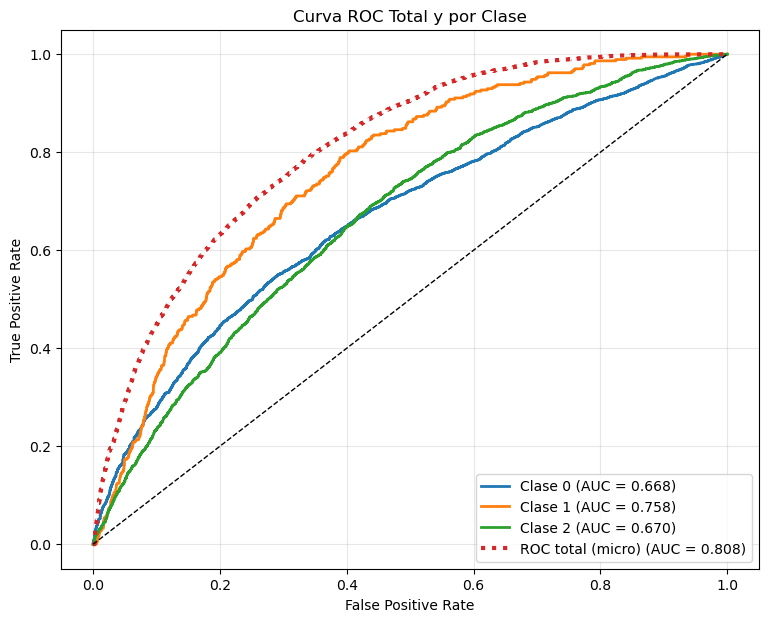

In [76]:
plt.figure(figsize=(9, 7))

# ROC por clase
for i, cls in enumerate(classes):
    fpr, tpr, _ = roc_curve(y_true_bin[:, i], y_proba[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(
        fpr, tpr,
        lw=2,
        label=f'Clase {cls} (AUC = {roc_auc:.3f})'
    )

# ROC TOTAL (micro-average)
fpr_micro, tpr_micro, _ = roc_curve(
    y_true_bin.ravel(),
    y_proba.ravel()
)
auc_micro = auc(fpr_micro, tpr_micro)

plt.plot(
    fpr_micro, tpr_micro,
    linestyle=':',
    linewidth=3,
    label=f'ROC total (micro) (AUC = {auc_micro:.3f})'
)

# Línea azar
plt.plot([0, 1], [0, 1], 'k--', lw=1)

plt.title('Curva ROC Total y por Clase')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.show()


### Modelo Binario

In [51]:
resultado_binario= resultado[['target','xgbB_pred_class','xgb_prob_class_1','xgb_prob_class_0','LGBM_B_pred_class','LGBM_B_prob_class_0','LGBM_B_prob_class_1','catB_pred_class','catB_prob_class_1','catB_prob_class_0']]
resultado_binario

,target,xgbB_pred_class,xgb_prob_class_1,xgb_prob_class_0,LGBM_B_pred_class,LGBM_B_prob_class_0,LGBM_B_prob_class_1,catB_pred_class,catB_prob_class_1,catB_prob_class_0
0,0,0,0.389513,0.610487,0,0.763140,0.236860,0,0.384456,0.615544
1,0,0,0.340346,0.659654,0,0.777975,0.222025,0,0.387231,0.612769
2,0,0,0.226924,0.773076,0,0.805708,0.194292,0,0.276112,0.723888
3,0,1,0.565900,0.434100,0,0.532052,0.467948,0,0.486975,0.513025
4,0,0,0.208254,0.791746,0,0.753808,0.246192,0,0.345004,0.654996
...,...,...,...,...,...,...,...,...,...,...
14205,1,0,0.397361,0.602639,0,0.599677,0.400323,0,0.378961,0.621039
14206,1,0,0.339613,0.660387,0,0.631338,0.368662,0,0.381410,0.618590
14207,1,0,0.424548,0.575452,0,0.515455,0.484545,1,0.522150,0.477850
14208,1,0,0.320636,0.679364,0,0.671040,0.328960,0,0.493989,0.506011


In [58]:
resultado_binario['target']= resultado_binario['target'].replace({2: 1})
resultado_binario

,target,xgbB_pred_class,xgb_prob_class_1,xgb_prob_class_0,LGBM_B_pred_class,LGBM_B_prob_class_0,LGBM_B_prob_class_1,catB_pred_class,catB_prob_class_1,catB_prob_class_0,votacion
0,0,0,0.389513,0.610487,0,0.763140,0.236860,0,0.384456,0.615544,0
1,0,0,0.340346,0.659654,0,0.777975,0.222025,0,0.387231,0.612769,0
2,0,0,0.226924,0.773076,0,0.805708,0.194292,0,0.276112,0.723888,0
3,0,1,0.565900,0.434100,0,0.532052,0.467948,0,0.486975,0.513025,0
4,0,0,0.208254,0.791746,0,0.753808,0.246192,0,0.345004,0.654996,0
...,...,...,...,...,...,...,...,...,...,...,...
14205,1,0,0.397361,0.602639,0,0.599677,0.400323,0,0.378961,0.621039,0
14206,1,0,0.339613,0.660387,0,0.631338,0.368662,0,0.381410,0.618590,0
14207,1,0,0.424548,0.575452,0,0.515455,0.484545,1,0.522150,0.477850,0
14208,1,0,0.320636,0.679364,0,0.671040,0.328960,0,0.493989,0.506011,0


In [59]:
#votación multitarget
resultado_binario['votacion'] = resultado_binario[['xgbB_pred_class', 'LGBM_B_pred_class','catB_pred_class']].mode(axis=1)[0]

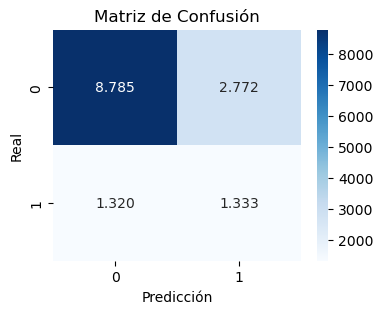

In [160]:
cm = confusion_matrix(resultado_binario['target'], resultado_binario['votacion'])
cm_fmt = [[f"{int(x):,}".replace(",", ".") for x in row] for row in cm]

plt.figure(figsize=(4, 3))
sns.heatmap(
    cm,
    annot=cm_fmt,
    fmt="",
    cmap="Blues"
)
#sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Matriz de Confusión")
plt.ylabel("Real")
plt.xlabel("Predicción")
plt.show()

In [61]:
accuracy = accuracy_score(
    resultado_binario['target'],
    resultado_binario['votacion']
)

print(f'Accuracy: {accuracy:.4f}')

Accuracy: 0.7120


In [62]:
print(classification_report(
    resultado_binario['target'],
    resultado_binario['votacion']
))

              precision    recall  f1-score   support

           0       0.87      0.76      0.81     11557
           1       0.32      0.50      0.39      2653

    accuracy                           0.71     14210
   macro avg       0.60      0.63      0.60     14210
weighted avg       0.77      0.71      0.73     14210



In [64]:
resultado_binario['proba_B_0'] = resultado_binario[['xgb_prob_class_0','LGBM_B_prob_class_0','catB_prob_class_0']].mean(axis=1)
resultado_binario['proba_B_1'] = resultado_binario[['xgb_prob_class_1','LGBM_B_prob_class_1','catB_prob_class_1']].mean(axis=1)


In [66]:
y_true = resultado_binario['target'].values
y_score = resultado_binario[['proba_B_0', 'proba_B_1']].values

y_true_bin = label_binarize(y_true, classes=[0, 1])
n_classes = y_true_bin.shape[1]

In [70]:
# Target real
y_true = resultado_binario['target'].values

# Probabilidades promedio
y_proba = resultado_binario[['proba_B_0', 'proba_B_1']].values
y_proba_pos = y_proba[:, 1]

# Clases
classes = [0, 1]

# Binarizar target
y_true_bin = label_binarize(y_true, classes=classes)


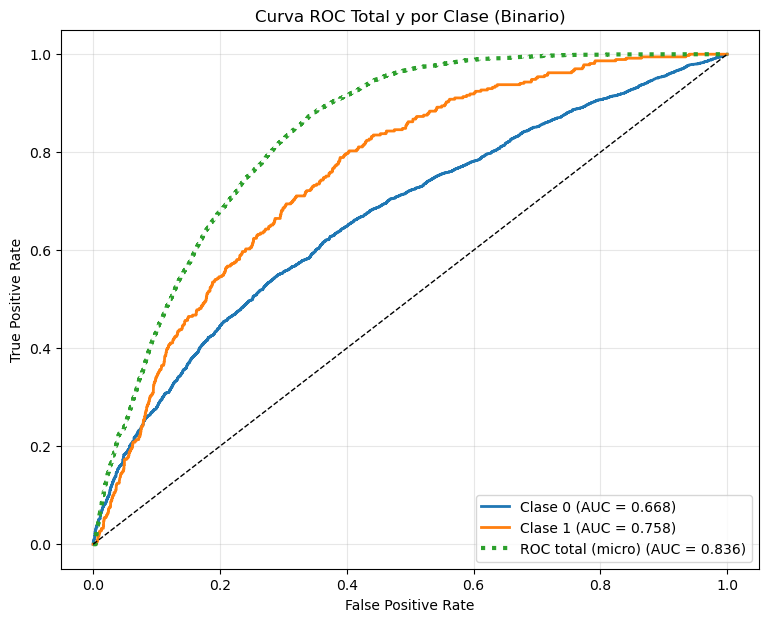

In [75]:

# Target real
y_true = resultado_multitarget['target'].values

# Probabilidades (2 clases)
y_proba = resultado_multitarget[['proba_M_0', 'proba_M_1']].values

# Clases
classes = [0, 1]

# Binarizar target (IGUAL que en 3 clases)
y_true_bin = label_binarize(y_true, classes=classes)

plt.figure(figsize=(9, 7))

# ROC por clase (0 y 1)
for i, cls in enumerate(classes):
    fpr, tpr, _ = roc_curve(y_true_bin[:, i], y_proba[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(
        fpr, tpr,
        lw=2,
        label=f'Clase {cls} (AUC = {roc_auc:.3f})'
    )

# ROC TOTAL (micro-average) — IGUAL que en 3 clases
fpr_micro, tpr_micro, _ = roc_curve(
    y_true_bin.ravel(),
    y_proba.ravel()
)
auc_micro = auc(fpr_micro, tpr_micro)

plt.plot(
    fpr_micro, tpr_micro,
    linestyle=':',
    linewidth=3,
    label=f'ROC total (micro) (AUC = {auc_micro:.3f})'
)

# Línea azar
plt.plot([0, 1], [0, 1], 'k--', lw=1)

plt.title('Curva ROC Total y por Clase (Binario)')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.show()



### Modelo Multitarget con métricas de grafos

In [78]:
resultado_multitarget_metricas = resultado[['target','xgb_pred_classMMG','xgb_prob_class_MMG1_0','xgb_prob_class_MMG1_1','xgb_prob_class_MMG1_2','LGBM_MMG_pred_class','LGBM_MMG_prob_class_0','LGBM_MMG_prob_class_1','LGBM_MMG_prob_class_2','catMMG_pred_class','catMMG_prob_class_0','catMMG_prob_class_1','catMMG_prob_class_2']]

In [ ]:
#para transformar object en float
resultado_multitarget_metricas["xgb_prob_class_MMG1_1"] = (
    resultado_multitarget_metricas["xgb_prob_class_MMG1_1"]
        .str.replace(",", ".", regex=False)
        .astype(float)
)

In [ ]:
#votación multitarget
resultado_multitarget_metricas['votacion'] = resultado_multitarget_metricas[['xgb_pred_classMMG','LGBM_MMG_pred_class','catMMG_pred_class']].mode(axis=1)[0]

In [ ]:
#suma de probabilidades
resultado_multitarget_metricas["votacion_sum0"] = resultado_multitarget_metricas[["xgb_prob_class_MMG1_0", "LGBM_MMG_prob_class_0", "catMMG_prob_class_0"]].sum(axis=1)
resultado_multitarget_metricas["votacion_sum1"] = resultado_multitarget_metricas[["xgb_prob_class_MMG1_1", "LGBM_MMG_prob_class_1", "catMMG_prob_class_1"]].sum(axis=1)
resultado_multitarget_metricas["votacion_sum2"] = resultado_multitarget_metricas[["xgb_prob_class_MMG1_2", "LGBM_MMG_prob_class_2", "catMMG_prob_class_2"]].sum(axis=1)
#el mayor
cols = ["votacion_sum0", "votacion_sum1", "votacion_sum2"]
resultado_multitarget_metricas["votacion"] = resultado_multitarget_metricas[cols].idxmax(axis=1).str[-1].astype(int)


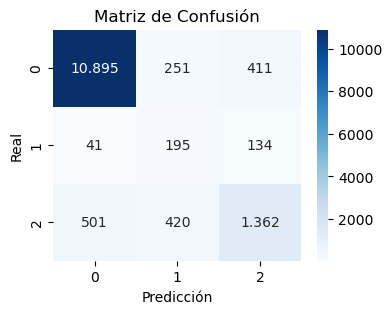

In [165]:
cm = confusion_matrix(resultado_multitarget_metricas['target'], resultado_multitarget_metricas['votacion'])

# Formatear números con separador de miles "."
cm_fmt = [[f"{int(x):,}".replace(",", ".") for x in row] for row in cm]

plt.figure(figsize=(4, 3))
sns.heatmap(
    cm,
    annot=cm_fmt,
    fmt="",
    cmap="Blues"
)
#sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Matriz de Confusión")
plt.ylabel("Real")
plt.xlabel("Predicción")
plt.show()

In [92]:
accuracy = accuracy_score(
    resultado_multitarget_metricas['target'],
    resultado_multitarget_metricas['votacion']
)

print(f'Accuracy: {accuracy:.4f}')

Accuracy: 0.8763


In [94]:
print(classification_report(
    resultado_multitarget_metricas['target'],
    resultado_multitarget_metricas['votacion']
))

              precision    recall  f1-score   support

           0       0.95      0.94      0.95     11557
           1       0.23      0.53      0.32       370
           2       0.71      0.60      0.65      2283

    accuracy                           0.88     14210
   macro avg       0.63      0.69      0.64     14210
weighted avg       0.90      0.88      0.88     14210



In [ ]:
resultado_multitarget_metricas['proba_M_0'] = resultado_multitarget_metricas[["xgb_prob_class_MMG1_0", "LGBM_MMG_prob_class_0", "catMMG_prob_class_0"]].mean(axis=1)
resultado_multitarget_metricas['proba_M_1'] = resultado_multitarget_metricas[["xgb_prob_class_MMG1_1", "LGBM_MMG_prob_class_1", "catMMG_prob_class_1"]].mean(axis=1)
resultado_multitarget_metricas['proba_M_2'] = resultado_multitarget_metricas[["xgb_prob_class_MMG1_2", "LGBM_MMG_prob_class_2", "catMMG_prob_class_2"]].mean(axis=1)

In [97]:
# Target real
y_true = resultado_multitarget_metricas['target'].values

# Probabilidades promedio
y_proba = resultado_multitarget_metricas[['proba_M_0', 'proba_M_1', 'proba_M_2']].values

# Clases
classes = [0, 1, 2]

# Binarizar target
y_true_bin = label_binarize(y_true, classes=classes)


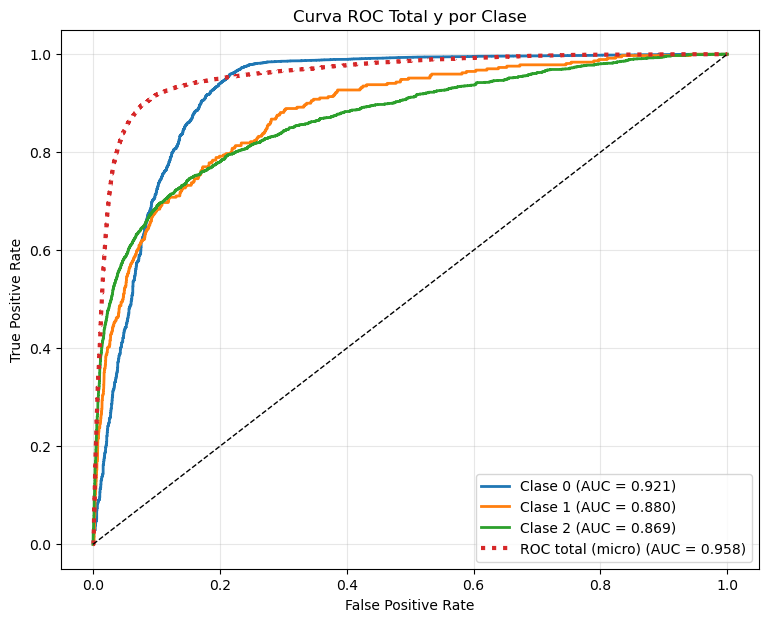

In [98]:
plt.figure(figsize=(9, 7))

# ROC por clase
for i, cls in enumerate(classes):
    fpr, tpr, _ = roc_curve(y_true_bin[:, i], y_proba[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(
        fpr, tpr,
        lw=2,
        label=f'Clase {cls} (AUC = {roc_auc:.3f})'
    )

# ROC TOTAL (micro-average)
fpr_micro, tpr_micro, _ = roc_curve(
    y_true_bin.ravel(),
    y_proba.ravel()
)
auc_micro = auc(fpr_micro, tpr_micro)

plt.plot(
    fpr_micro, tpr_micro,
    linestyle=':',
    linewidth=3,
    label=f'ROC total (micro) (AUC = {auc_micro:.3f})'
)

# Línea azar
plt.plot([0, 1], [0, 1], 'k--', lw=1)

plt.title('Curva ROC Total y por Clase')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.show()

## Ensamble Ponderado

#### Se realiza una prueba ponderando en ensamble según el modelo individual dónde se obtuvo mejor resultados, con el fin de obtener mejores resultados

In [ ]:
resultado_multitarget["votacion_sum0"] =  (
    resultado_multitarget["xgb_prob_class_M1_0"] * 0.2 +
    resultado_multitarget["LGBM_M_prob_class_0"] * 0.6 +
    resultado_multitarget["catM_prob_class_0"] * 0.2
)
resultado_multitarget["votacion_sum1"] = (
    resultado_multitarget["xgb_prob_class_M1_1"] * 0.2+
    resultado_multitarget["LGBM_M_prob_class_1"] * 0.6 +
    resultado_multitarget["catM_prob_class_1"] * 0.2
)
resultado_multitarget["votacion_sum2"] = (
    resultado_multitarget["xgb_prob_class_M1_2"] * 0.6 +
    resultado_multitarget["LGBM_M_prob_class_2"] * 0.2 +
    resultado_multitarget["catM_prob_class_2"] * 0.2
)

In [ ]:
cols = ["votacion_sum0", "votacion_sum1", "votacion_sum2"]

resultado_multitarget["votacion"] = (
    resultado_multitarget[cols]
    .idxmax(axis=1)
    .str[-1]
    .astype(int)
)

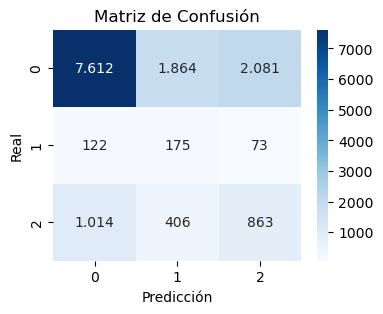

In [161]:
cm = confusion_matrix(resultado_multitarget['target'], resultado_multitarget['votacion'])

cm_fmt = [[f"{int(x):,}".replace(",", ".") for x in row] for row in cm]

plt.figure(figsize=(4, 3))
sns.heatmap(
    cm,
    annot=cm_fmt,
    fmt="",
    cmap="Blues"
)
#sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Matriz de Confusión")
plt.ylabel("Real")
plt.xlabel("Predicción")
plt.show()